In [19]:
pip install scikit-fuzzy

In [20]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

In [21]:
# Input variables
temperature = ctrl.Antecedent(np.arange(10, 41, 1), 'temperature')
humidity = ctrl.Antecedent(np.arange(20, 101, 1), 'humidity')
growth_stage = ctrl.Antecedent(np.arange(1, 4, 1), 'growth_stage')

# Output variables
fan_power = ctrl.Consequent(np.arange(0, 101, 1), 'fan_power')
misting = ctrl.Consequent(np.arange(0, 101, 1), 'misting')

In [22]:
# temperature MF
temperature['very_low'] = fuzz.trapmf(temperature.universe, [10, 10, 14, 16])
temperature['low'] = fuzz.trimf(temperature.universe, [14, 18, 22])
temperature['optimal'] = fuzz.trapmf(temperature.universe, [18, 22, 26, 28])
temperature['high'] = fuzz.trimf(temperature.universe, [26, 30, 34])
temperature['very_high'] = fuzz.trapmf(temperature.universe, [32, 35, 40, 40])

In [23]:
# humidity MF
humidity['very_dry'] = fuzz.trapmf(humidity.universe, [20, 20, 30, 35])
humidity['dry'] = fuzz.trimf(humidity.universe, [30, 40, 50])
humidity['optimal'] = fuzz.trapmf(humidity.universe, [45, 55, 65, 70])
humidity['humid'] = fuzz.trimf(humidity.universe, [65, 75, 85])
humidity['very_humid'] = fuzz.trapmf(humidity.universe, [80, 85, 100, 100])

In [24]:
# growth stage MF
growth_stage['seedling'] = fuzz.trimf(growth_stage.universe, [1, 1, 2])
growth_stage['vegetative'] = fuzz.trimf(growth_stage.universe, [1, 2, 3])
growth_stage['flowering'] = fuzz.trimf(growth_stage.universe, [2, 3, 3])

In [25]:
# output MF
fan_power['off'] = fuzz.trimf(fan_power.universe, [0, 0, 10])
fan_power['low'] = fuzz.trimf(fan_power.universe, [10, 30, 50])
fan_power['medium'] = fuzz.trimf(fan_power.universe, [40, 60, 80])
fan_power['high'] = fuzz.trimf(fan_power.universe, [70, 85, 100])
fan_power['very_high'] = fuzz.trimf(fan_power.universe, [85, 100, 100])

misting['off'] = fuzz.trimf(misting.universe, [0, 0, 10])
misting['low'] = fuzz.trimf(misting.universe, [10, 30, 50])
misting['medium'] = fuzz.trimf(misting.universe, [40, 60, 80])
misting['high'] = fuzz.trimf(misting.universe, [70, 85, 100])
misting['very_high'] = fuzz.trimf(misting.universe, [85, 100, 100])

In [26]:
# mamdani rules
rules = []

# temperature-humidity rules
# Very Low Temperature
rules.append(ctrl.Rule(temperature['very_low'] & humidity['very_dry'],
                        (fan_power['high'], misting['medium'])))

rules.append(ctrl.Rule(temperature['very_low'] & humidity['optimal'],
                        (fan_power['high'], misting['low'])))

rules.append(ctrl.Rule(temperature['very_low'] & humidity['very_humid'],
                        (fan_power['medium'], misting['off'])))

# Low Temperature
rules.append(ctrl.Rule(temperature['low'] & humidity['dry'],
                        (fan_power['medium'], misting['medium'])))

rules.append(ctrl.Rule(temperature['low'] & humidity['optimal'],
                        (fan_power['medium'], misting['low'])))

rules.append(ctrl.Rule(temperature['low'] & humidity['humid'],
                        (fan_power['low'], misting['off'])))

# Optimal Temperature
rules.append(ctrl.Rule(temperature['optimal'] & humidity['very_dry'],
                        (fan_power['low'], misting['high'])))

rules.append(ctrl.Rule(temperature['optimal'] & humidity['dry'],
                        (fan_power['low'], misting['medium'])))

rules.append(ctrl.Rule(temperature['optimal'] & humidity['optimal'],
                        (fan_power['low'], misting['low'])))

rules.append(ctrl.Rule(temperature['optimal'] & humidity['humid'],
                        (fan_power['medium'], misting['off'])))

# High Temperature
rules.append(ctrl.Rule(temperature['high'] & humidity['very_dry'],
                        (fan_power['high'], misting['high'])))

rules.append(ctrl.Rule(temperature['high'] & humidity['dry'],
                        (fan_power['high'], misting['medium'])))

rules.append(ctrl.Rule(temperature['high'] & humidity['optimal'],
                        (fan_power['medium'], misting['low'])))

# Very High Temperature
rules.append(ctrl.Rule(temperature['very_high'] & humidity['dry'],
                        (fan_power['very_high'], misting['high'])))

rules.append(ctrl.Rule(temperature['very_high'] & humidity['very_humid'],
                        (fan_power['very_high'], misting['off'])))

# growth stage
# Seedling stage (gentle control)
rules.append(ctrl.Rule(growth_stage['seedling'] & temperature['low'],
                        fan_power['medium']))

rules.append(ctrl.Rule(growth_stage['seedling'] & humidity['dry'],
                        misting['medium']))

rules.append(ctrl.Rule(growth_stage['seedling'] & temperature['very_high'],
                        fan_power['high']))

# Vegetative stage (stable control)
rules.append(ctrl.Rule(growth_stage['vegetative'] & temperature['optimal'],
                        fan_power['low']))

rules.append(ctrl.Rule(growth_stage['vegetative'] & humidity['optimal'],
                        misting['low']))

rules.append(ctrl.Rule(growth_stage['vegetative'] & humidity['very_humid'],
                        misting['off']))

# Flowering stage (humidity-sensitive)
rules.append(ctrl.Rule(growth_stage['flowering'] & humidity['dry'],
                        misting['high']))

rules.append(ctrl.Rule(growth_stage['flowering'] & temperature['high'],
                        fan_power['medium']))

rules.append(ctrl.Rule(growth_stage['flowering'] & temperature['low'],
                        fan_power['low']))

rules.append(ctrl.Rule(growth_stage['flowering'] & humidity['very_humid'],
                        misting['off']))


In [27]:
# control system
greenhouse_ctrl = ctrl.ControlSystem(rules)
greenhouse_sim = ctrl.ControlSystemSimulation(greenhouse_ctrl)

In [28]:
# simulation object
greenhouse_sim = ctrl.ControlSystemSimulation(greenhouse_ctrl)

In [29]:
# test
# Sample input values
greenhouse_sim.input['temperature'] = 30
greenhouse_sim.input['humidity'] = 40
greenhouse_sim.input['growth_stage'] = 1  # Seedling

# Compute result
greenhouse_sim.compute()

print("Fan Power Output:", greenhouse_sim.output['fan_power'])
print("Misting Output:", greenhouse_sim.output['misting'])

Fan Power Output: 85.00000000000001
Misting Output: 60.00000000000002


In [30]:
# adaption function
def apply_adaptation(fan, mist, stage):
    """
    Adaptive scaling based on plant growth stage
    """

    if stage == 1:  # Seedling
        fan *= 0.8
        mist *= 1.2

    elif stage == 2:  # Vegetative
        fan *= 1.0
        mist *= 1.0

    elif stage == 3:  # Flowering
        fan *= 1.1
        mist *= 1.3

    # Ensure outputs stay within bounds
    fan = min(max(fan, 0), 100)
    mist = min(max(mist, 0), 100)

    return fan, mist

In [31]:
# Mamdani output
fan_raw = greenhouse_sim.output['fan_power']
mist_raw = greenhouse_sim.output['misting']

# Apply adaptation
fan_adapted, mist_adapted = apply_adaptation(
    fan_raw,
    mist_raw,
    stage=1  # Seedling
)

print("Adapted Fan Power:", round(fan_adapted, 2))
print("Adapted Misting:", round(mist_adapted, 2))

Adapted Fan Power: 68.0
Adapted Misting: 72.0


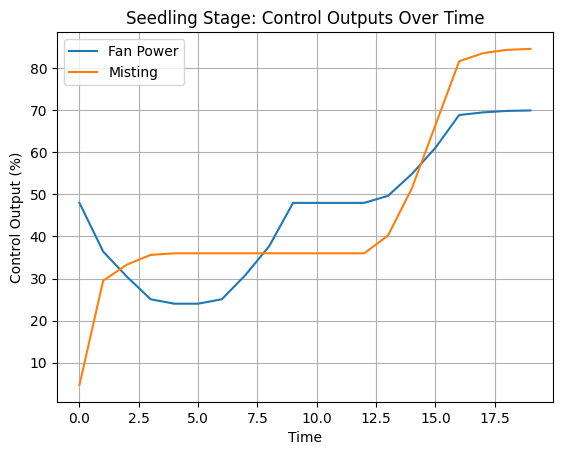

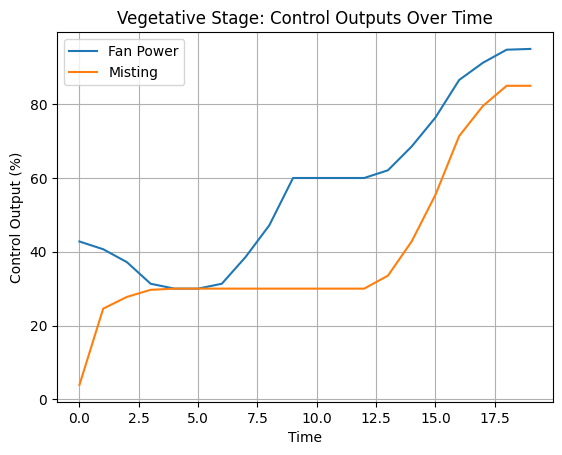

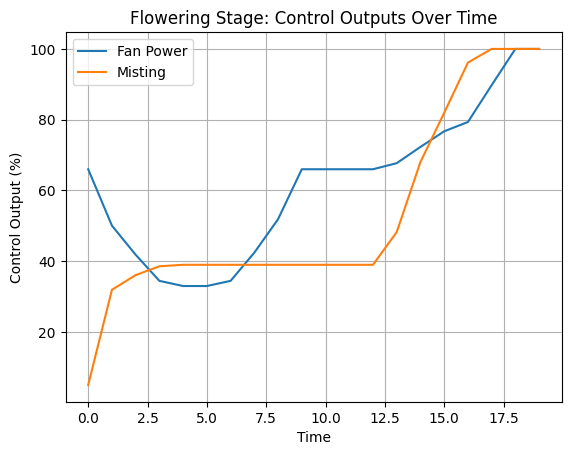

In [32]:
# plotting
def mamdani_with_adaptation(temp, hum, stage):
    greenhouse_sim.input['temperature'] = temp
    greenhouse_sim.input['humidity'] = hum
    greenhouse_sim.input['growth_stage'] = stage

    greenhouse_sim.compute()

    fan = greenhouse_sim.output['fan_power']
    mist = greenhouse_sim.output['misting']

    fan, mist = apply_adaptation(fan, mist, stage)

    return fan, mist

time_steps = np.arange(0, 20)

# Weather conditions changing over time
temperature_profile = np.linspace(22, 35, len(time_steps))
humidity_profile = np.linspace(70, 40, len(time_steps))

# seeding stage
fan_seedling = []
mist_seedling = []

for t, h in zip(temperature_profile, humidity_profile):
    fan, mist = mamdani_with_adaptation(t, h, stage=1)
    fan_seedling.append(fan)
    mist_seedling.append(mist)

plt.figure()
plt.plot(time_steps, fan_seedling, label='Fan Power')
plt.plot(time_steps, mist_seedling, label='Misting')
plt.xlabel('Time')
plt.ylabel('Control Output (%)')
plt.title('Seedling Stage: Control Outputs Over Time')
plt.legend()
plt.grid(True)
plt.show()

# vegetative stage
fan_vegetative = []
mist_vegetative = []

for t, h in zip(temperature_profile, humidity_profile):
    fan, mist = mamdani_with_adaptation(t, h, stage=2)
    fan_vegetative.append(fan)
    mist_vegetative.append(mist)

plt.figure()
plt.plot(time_steps, fan_vegetative, label='Fan Power')
plt.plot(time_steps, mist_vegetative, label='Misting')
plt.xlabel('Time')
plt.ylabel('Control Output (%)')
plt.title('Vegetative Stage: Control Outputs Over Time')
plt.legend()
plt.grid(True)
plt.show()

# flowering stage
fan_flowering = []
mist_flowering = []

for t, h in zip(temperature_profile, humidity_profile):
    fan, mist = mamdani_with_adaptation(t, h, stage=3)
    fan_flowering.append(fan)
    mist_flowering.append(mist)

plt.figure()
plt.plot(time_steps, fan_flowering, label='Fan Power')
plt.plot(time_steps, mist_flowering, label='Misting')
plt.xlabel('Time')
plt.ylabel('Control Output (%)')
plt.title('Flowering Stage: Control Outputs Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# performance evalutaion with 20 test simulations
import numpy as np
import time
import pandas as pd

# -------------------------------
# CONFIGURATION
# -------------------------------
def sugeno_controller(temp, hum, stage):
    """
    Simple Sugeno-style controller
    Outputs are crisp linear functions
    """

    # Fan power (linear model)
    fan = 2.5 * (temp - 20) - 0.8 * (hum - 50)

    # Misting level (linear model)
    mist = 1.5 * (50 - hum) + 0.5 * (temp - 25)

    # Stage sensitivity
    if stage == 1:       # Seedling
        fan *= 0.8
        mist *= 1.2
    elif stage == 3:     # Flowering
        fan *= 1.1
        mist *= 1.3

    fan = min(max(fan, 0), 100)
    mist = min(max(mist, 0), 100)

    return fan, mist

np.random.seed(42)
N_TESTS = 20
stage = 3  # Flowering stage for fair comparison

# Random weather conditions
temps = np.random.uniform(18, 40, N_TESTS)
hums = np.random.uniform(25, 85, N_TESTS)

# Storage
mamdani_outputs = []
sugeno_outputs = []

mamdani_times = []
sugeno_times = []

# -------------------------------
# RUN 20 RANDOM TEST SIMULATIONS
# -------------------------------
for t, h in zip(temps, hums):

    # Mamdani
    start = time.time()
    fan_m, mist_m = mamdani_with_adaptation(t, h, stage)
    mamdani_times.append(time.time() - start)
    mamdani_outputs.append((fan_m, mist_m))

    # Sugeno
    start = time.time()
    fan_s, mist_s = sugeno_controller(t, h, stage)
    sugeno_times.append(time.time() - start)
    sugeno_outputs.append((fan_s, mist_s))

# Convert to arrays
mamdani_outputs = np.array(mamdani_outputs)
sugeno_outputs = np.array(sugeno_outputs)

# -------------------------------
# METRIC CALCULATIONS
# -------------------------------

# Avg Response Time (seconds)
avg_time_mamdani = np.mean(mamdani_times)
avg_time_sugeno = np.mean(sugeno_times)

# Avg Error (difference between fan & mist as control imbalance proxy)
avg_error_mamdani = np.mean(np.abs(mamdani_outputs[:,0] - mamdani_outputs[:,1]))
avg_error_sugeno = np.mean(np.abs(sugeno_outputs[:,0] - sugeno_outputs[:,1]))

# Energy Usage (fan weighted more than misting)
energy_mamdani = np.mean(0.7 * mamdani_outputs[:,0] + 0.3 * mamdani_outputs[:,1])
energy_sugeno = np.mean(0.7 * sugeno_outputs[:,0] + 0.3 * sugeno_outputs[:,1])

# Smoothness Score (lower change = smoother → invert for score)
def smoothness_score(signal):
    return 1 / (1 + np.mean(np.abs(np.diff(signal))))

smooth_mamdani = smoothness_score(mamdani_outputs[:,0])
smooth_sugeno = smoothness_score(sugeno_outputs[:,0])

# -------------------------------
# COMPARISON TABLE
# -------------------------------
comparison_table = pd.DataFrame({
    "Controller Type": ["Mamdani", "Sugeno"],
    "Avg Response Time (s)": [round(avg_time_mamdani, 5), round(avg_time_sugeno, 5)],
    "Avg Error": [round(avg_error_mamdani, 2), round(avg_error_sugeno, 2)],
    "Energy Usage": [round(energy_mamdani, 2), round(energy_sugeno, 2)],
    "Smoothness Score": [round(smooth_mamdani, 3), round(smooth_sugeno, 3)]
})

print("\n=== PERFORMANCE COMPARISON TABLE (20 RANDOM TESTS) ===\n")
comparison_table



=== PERFORMANCE COMPARISON TABLE (20 RANDOM TESTS) ===



,Controller Type,Avg Response Time (s),Avg Error,Energy Usage,Smoothness Score
0,Mamdani,0.01172,24.62,63.34,0.044
1,Sugeno,0.00001,11.74,21.48,0.037
